# V16 – Netzwerktechnik Teil 2: Praxis

## 🎯 Lernziele
Nach diesem Notebook kannst du …
- `sensoren_daten.csv` mit Pandas einlesen und mit `head`, `shape`, `describe` inspizieren,
- einzelne Spalten selektieren und aggregieren (`mean`, `max`, `count`),
- Zeilen mit einer **Boolean-Maske** filtern,
- Gruppen mit `groupby` bilden und pro Gruppe einen Mittelwert berechnen,
- eine Series mit `.plot()` visualisieren.

## ⏱️ Zeitbudget
Ca. 30 Minuten.

## 🧭 TL;DR
Ein durchgehendes Tutorial auf den 15 Sensor-Messungen: einlesen, verstehen, filtern, gruppieren, plotten. Drei Fill-in-Blanks mit Selbstkontrolle und eine kleine Abschluss-Challenge.

## 📦 Voraussetzungen
- [00_python_recap.ipynb](00_python_recap.ipynb)
- [01_theorie.ipynb](01_theorie.ipynb)

## 1. DataFrame laden und reinschauen

Beginn wie immer: `import pandas as pd`, dann `pd.read_csv(pfad)`. Mit `df.shape` siehst du sofort Zeilen-/Spalten-Zahl, mit `df.head()` die ersten fünf Zeilen.

In [1]:
import pandas as pd

df = pd.read_csv("sensoren_daten.csv")
print("Form:", df.shape)
df.head()

Form: (15, 9)


,Sensor_ID,Sensor_Name,Typ,Position,Temperatur_C,Vibration_mm_s,Druck_bar,Letztwartung,Status
0,S001,Temp-Sensor-01,Temperatur,Linie_A_Spindel,78.5,0.15,5.2,2024-11-15,Aktiv
1,S002,Vib-Sensor-01,Vibration,Linie_A_Lager,45.2,2.35,4.8,2024-10-22,Aktiv
2,S003,Druck-Sensor-01,Druck,Linie_A_Hydraulik,23.1,0.08,152.3,2024-12-01,Aktiv
3,S004,Temp-Sensor-02,Temperatur,Linie_B_Spindel,92.3,0.22,5.5,2024-09-18,Warnung
4,S005,Vib-Sensor-02,Vibration,Linie_B_Lager,52.8,4.82,5.1,2024-11-30,Kritisch


### 1.1 Numerische Übersicht mit `describe`

`describe()` zeigt pro numerischer Spalte die wichtigsten Statistiken. Achte auf `max` vs. `75 %` – ein großer Abstand deutet auf Ausreißer hin.

In [2]:
df.describe()

,Temperatur_C,Vibration_mm_s,Druck_bar
count,15.000000,15.000000,15.000000
mean,53.700000,1.308000,50.726667
std,27.364811,1.939765,67.842048
min,19.500000,0.060000,4.700000
25%,30.050000,0.105000,5.150000
50%,48.300000,0.220000,5.800000
75%,71.800000,1.935000,120.350000
max,105.200000,5.920000,165.800000


## 2. Spalten und Aggregationen

Mit `df["spalte"]` bekommst du die Spalte als Series und kannst direkt aggregieren.

In [3]:
print("Mittlere Temperatur:", round(df["Temperatur_C"].mean(), 2))
print("Maximum Vibration: ", df["Vibration_mm_s"].max())
print("Anzahl Messungen: ", df.shape[0])

Mittlere Temperatur: 53.7
Maximum Vibration:  5.92
Anzahl Messungen:  15


### 2.1 Fill-in-Blank 1 – Maximum Temperatur

Speichere den **maximalen Temperatur-Wert** aus `df["Temperatur_C"]` in der Variablen `max_temp`.

In [4]:
# TODO: Maximum der Spalte Temperatur_C bestimmen
max_temp = 0.0

print("max_temp =", max_temp)

max_temp = 0.0


In [5]:
# ▶️ Selbstkontrolle
try:
    assert max_temp == 105.2, f"Erwartet 105.2, bekommen {max_temp}"
    print("✅ Fill-in 1 gelöst.")
except AssertionError as e:
    print(f"❌ {e}")
except NameError:
    print("❌ Variable `max_temp` fehlt.")

❌ Erwartet 105.2, bekommen 0.0


## 3. Filtern mit Boolean-Masken

`df[df["spalte"] bedingung]` liefert nur die Zeilen, die die Bedingung erfüllen. Beispiel: alle Sensoren mit Status `Kritisch`.

In [6]:
kritisch = df[df["Status"] == "Kritisch"]
print(f"{len(kritisch)} kritische Sensoren:")
kritisch[["Sensor_ID", "Sensor_Name", "Vibration_mm_s"]]

3 kritische Sensoren:


,Sensor_ID,Sensor_Name,Vibration_mm_s
4,S005,Vib-Sensor-02,4.82
12,S013,Temp-Sensor-05,0.35
13,S014,Vib-Sensor-05,5.92


### 3.1 Fill-in-Blank 2 – Anzahl heißer Sensoren

Zähle mit einer Boolean-Maske die Sensoren, deren `Temperatur_C` **größer oder gleich 80** ist, und speichere die Anzahl in `anzahl_heiss`.

In [7]:
# TODO: Maske bauen, Zeilen zählen
anzahl_heiss = 0

print("anzahl_heiss =", anzahl_heiss)

anzahl_heiss = 0


In [8]:
# ▶️ Selbstkontrolle
# Temperaturen >= 80: S013 (105.2), S004 (92.3), S010 (88.7) → 3
try:
    assert anzahl_heiss == 3, f"Erwartet 3, bekommen {anzahl_heiss}"
    print("✅ Fill-in 2 gelöst.")
except AssertionError as e:
    print(f"❌ {e}")
except NameError:
    print("❌ Variable `anzahl_heiss` fehlt.")

❌ Erwartet 3, bekommen 0


## 4. Gruppieren mit `groupby`

Wir wollen pro Sensor-Typ (Temperatur/Vibration/Druck) den Mittelwert von `Temperatur_C` sehen.

In [9]:
mittel_pro_typ = df.groupby("Typ")["Temperatur_C"].mean()
print(mittel_pro_typ)

Typ
Druck         25.82
Temperatur    85.96
Vibration     49.32
Name: Temperatur_C, dtype: float64


### 4.1 Fill-in-Blank 3 – Typ mit höchstem Mittelwert

Nutze `.idxmax()` auf der obigen Series, um den **Namen** des Sensor-Typs mit der höchsten mittleren Temperatur zu bekommen. Speichere das Ergebnis als String in `bester_typ`.

In [10]:
# TODO: mittel_pro_typ.idxmax() aufrufen
bester_typ = ""

print("bester_typ =", bester_typ)

bester_typ = 


In [11]:
# ▶️ Selbstkontrolle
try:
    assert bester_typ == "Temperatur", f"Erwartet 'Temperatur', bekommen '{bester_typ}'"
    print("✅ Fill-in 3 gelöst.")
except AssertionError as e:
    print(f"❌ {e}")
except NameError:
    print("❌ Variable `bester_typ` fehlt.")

❌ Erwartet 'Temperatur', bekommen ''


## 5. Plot einer Series

Mit `.plot()` bekommst du einen Schnell-Plot. Für einen Balken-Vergleich der Gruppen setzen wir `kind="bar"`.

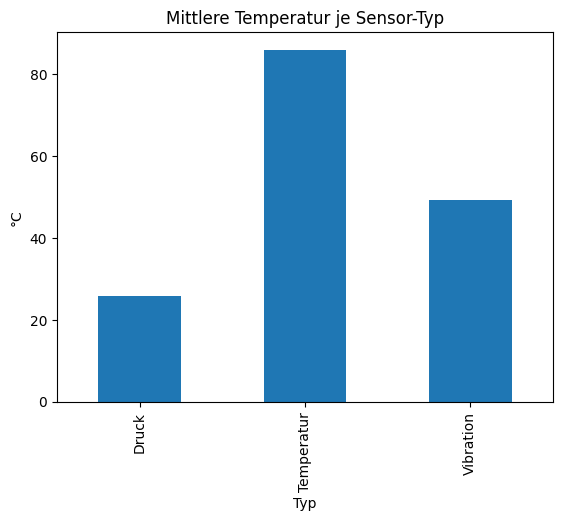

In [12]:
import matplotlib.pyplot as plt

mittel_pro_typ.plot(kind="bar", title="Mittlere Temperatur je Sensor-Typ")
plt.ylabel("°C")
plt.show()

## 6. Mini-Challenge – Sortierter Überblick

Berechne den Mittelwert der Spalte `Vibration_mm_s` pro Typ, sortiere die resultierende Series **absteigend** und speichere den **Typ mit der höchsten mittleren Vibration** in `top_vibration_typ`.

**Tipp:** `.sort_values(ascending=False)` auf der Series, danach `.index[0]` – oder kürzer `.idxmax()`.

In [13]:
# TODO: groupby nach Typ, Mittelwert Vibration_mm_s, idxmax
top_vibration_typ = ""

print("top_vibration_typ =", top_vibration_typ)

top_vibration_typ = 


In [14]:
# ▶️ Selbstkontrolle
# Vibration_mm_s-Mittel: Temperatur=0.222, Vibration=3.612, Druck=0.09 → Vibration
try:
    assert top_vibration_typ == "Vibration", f"Erwartet 'Vibration', bekommen '{top_vibration_typ}'"
    print("✅ Mini-Challenge gelöst.")
except AssertionError as e:
    print(f"❌ {e}")
except NameError:
    print("❌ Variable `top_vibration_typ` fehlt.")

❌ Erwartet 'Vibration', bekommen ''


## ✅ Zusammenfassung
- CSV-Dateien lädst du mit `pd.read_csv(pfad)` in einen DataFrame.
- `describe()` liefert numerische Statistik auf einen Blick.
- Mit Boolean-Masken filterst du Zeilen (`df[df["spalte"] op wert]`).
- `groupby(...)["ziel"].aggregation()` ist das Standard-Werkzeug für Fragen „pro Gruppe".
- `.idxmax()` liefert den **Index** der Zeile mit dem Maximum – das ist oft der gesuchte Name.
- `.plot()` ist der schnellste Weg zu einer ersten Visualisierung.

## ➡️ Nächster Schritt
Weiter mit [03_aufgaben.ipynb](03_aufgaben.ipynb) – fünf Übungsaufgaben auf echten Testdaten.